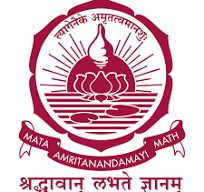

MFC Project

---


C-24 Team Members
*   Cibikumar (CB.SC.U4AIE24212)
*   Naveen K (CB.SC.U4AIE24235)
*   Subash B (CB.SC.U4AIE24254)
*   Manas T (CB.SC.U4AIE24257)

# **1. Linear Regression Model**

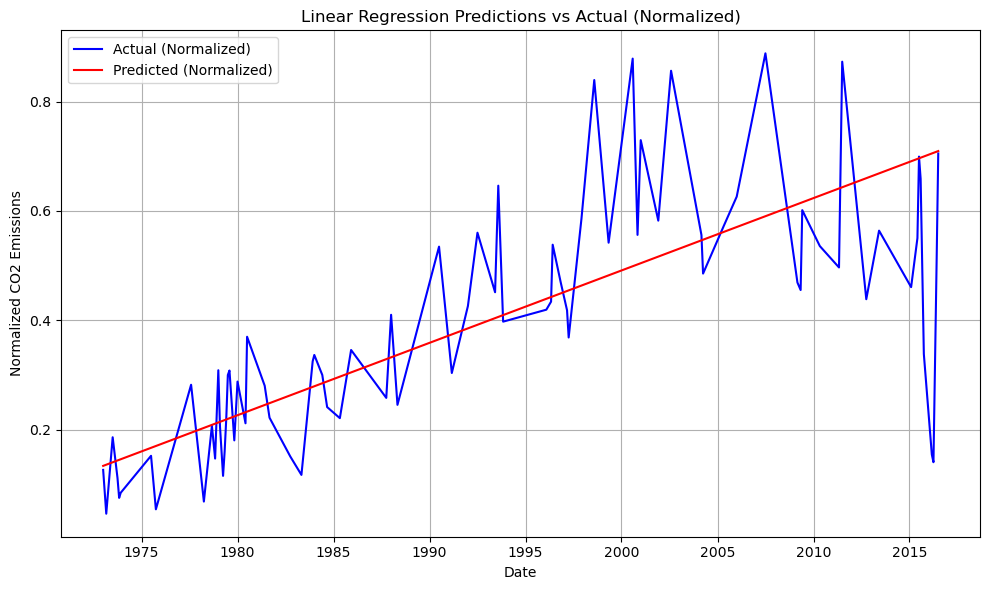

      Metric     Value
0       RMSE  0.157288
1        MAE  0.107850
2        MSE  0.024740
3  R-squared  0.467634


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('C:/Users/subas/OneDrive/Desktop/MFC/cleaned_monthly_sectoral_dataset.csv')

# Convert 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Convert 'Date' to numerical values (ordinal)
data['DateOrdinal'] = data['Date'].map(pd.Timestamp.toordinal)

# Extract features and target variable
X = data[['DateOrdinal']]
y = data['Total Energy Electric Power Sector CO2 Emissions'].values.reshape(-1, 1)

# Normalize the target variable
scaler = MinMaxScaler()
y_normalized = scaler.fit_transform(y)

# Split the data
X_train, X_test, y_train_normalized, y_test_normalized = train_test_split(
    X, y_normalized, test_size=0.15, random_state=42
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train_normalized)

# Predict
y_pred_normalized = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test_normalized, y_pred_normalized)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_normalized, y_pred_normalized)
r2 = r2_score(y_test_normalized, y_pred_normalized)

# Results
results_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MSE', 'R-squared'],
    'Value': [rmse, mae, mse, r2]
})

# Merge X_test with corresponding dates
X_test_with_dates = X_test.copy()
X_test_with_dates['Date'] = X_test_with_dates['DateOrdinal'].map(pd.Timestamp.fromordinal)

# Sort by Date for better plotting
X_test_with_dates['Actual'] = y_test_normalized
X_test_with_dates['Predicted'] = y_pred_normalized
X_test_with_dates.sort_values('Date', inplace=True)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(X_test_with_dates['Date'], X_test_with_dates['Actual'], label='Actual (Normalized)', color='blue')
plt.plot(X_test_with_dates['Date'], X_test_with_dates['Predicted'], label='Predicted (Normalized)', color='red')
plt.xlabel('Date')
plt.ylabel('Normalized CO2 Emissions')
plt.title('Linear Regression Predictions vs Actual (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print results
print(results_df)


# **2. LightGBM Model**

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000185 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 944
[LightGBM] [Info] Number of data points in the train set: 444, number of used features: 8
[LightGBM] [Info] Start training from score 0.404707
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

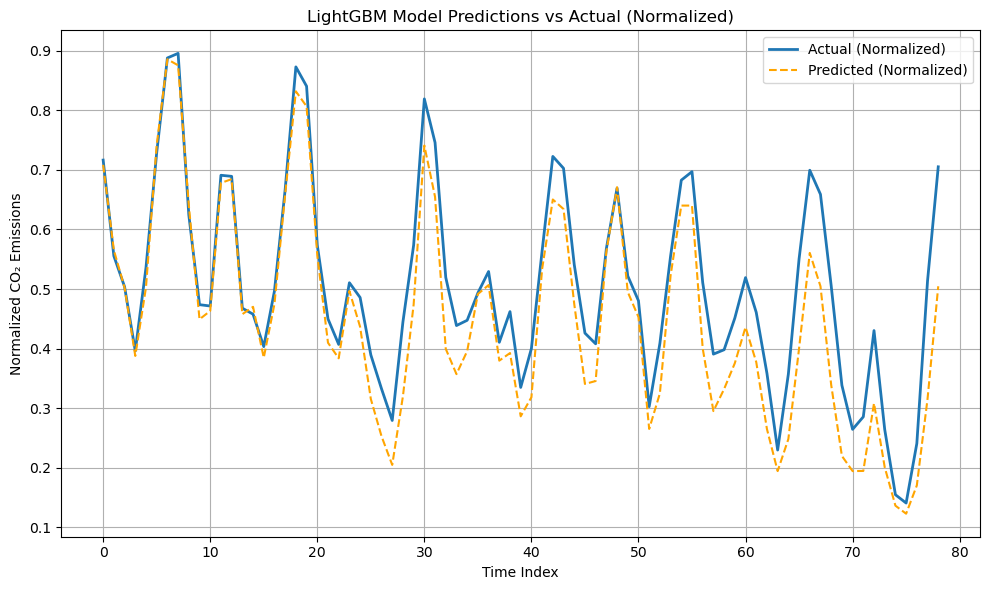

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor

# Load dataset
data = pd.read_csv('C:/Users/subas/OneDrive/Desktop/MFC/cleaned_monthly_sectoral_dataset.csv')

# Convert 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')

# Interpolate missing values linearly
data.interpolate(method='linear', inplace=True)

# Define the target column
target_column = 'Total Energy Electric Power Sector CO2 Emissions'

# Separate features and target
features = data.drop(columns=['Date', target_column])
target = data[[target_column]]

# Clean feature column names for LightGBM compatibility
features.columns = features.columns.str.replace(r'[^\w\s]', '', regex=True).str.replace(' ', '_')

# Normalize features
feature_scaler = StandardScaler()
features_scaled = feature_scaler.fit_transform(features)

# Normalize target (to 0–1 range)
target_scaler = MinMaxScaler()
target_scaled = target_scaler.fit_transform(target)

# Create DataFrames
X = pd.DataFrame(features_scaled, columns=features.columns)
y = pd.Series(target_scaled.flatten(), name=target_column)

# Train/test split (85% train, 15% test)
train_ratio = 0.85
split_index = int(len(X) * train_ratio)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Train the LightGBM model
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    objective='regression',
    random_state=42
)
lgb_model.fit(X_train, y_train)

# Predict
y_pred = lgb_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Output metrics
print("LightGBM Model Performance (Target Normalized to [0, 1]):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual (Normalized)', linewidth=2)
plt.plot(y_pred, label='Predicted (Normalized)', linestyle='--', color='orange')
plt.xlabel('Time Index')
plt.ylabel('Normalized CO₂ Emissions')
plt.title('LightGBM Model Predictions vs Actual (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **3. XGBoost Model**

Model Performance Metrics (Target Normalized to [0, 1]):
XGBoost RMSE: 0.0723
XGBoost MAE: 0.0542
XGBoost MSE: 0.0052
XGBoost R² Score: 0.8084


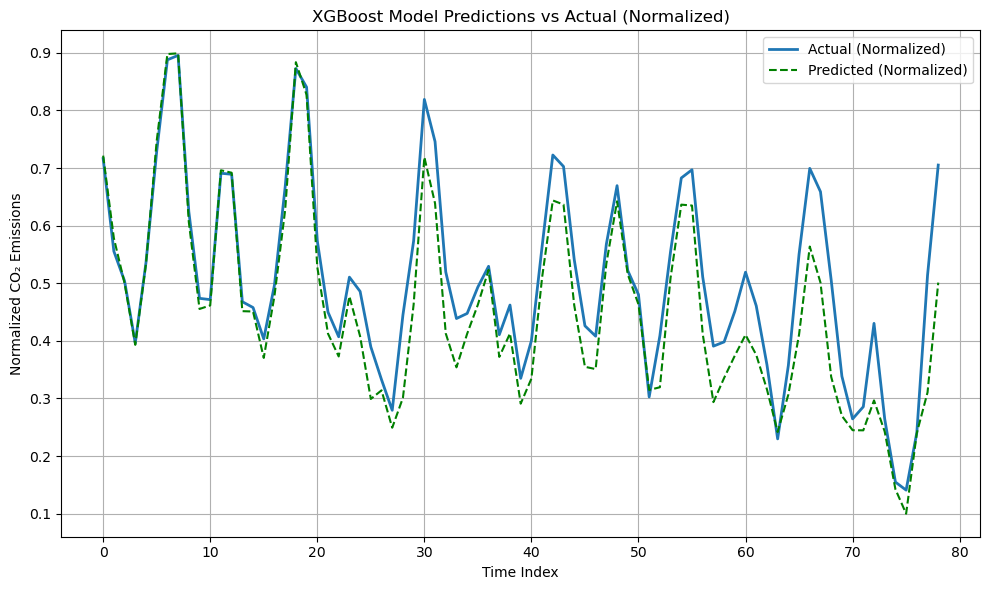

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Load dataset
data = pd.read_csv('C:/Users/subas/OneDrive/Desktop/MFC/cleaned_monthly_sectoral_dataset.csv')

# Convert 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')

# Interpolate missing values linearly
data.interpolate(method='linear', inplace=True)

# Define the target column
target_column = 'Total Energy Electric Power Sector CO2 Emissions'

# Separate features and target
features = data.drop(columns=['Date', target_column])
target = data[[target_column]]

# Normalize features with StandardScaler
feature_scaler = StandardScaler()
features_scaled = feature_scaler.fit_transform(features)

# Normalize target with MinMaxScaler to get values in [0, 1]
target_scaler = MinMaxScaler()
target_scaled = target_scaler.fit_transform(target)

# Convert to DataFrames
X = pd.DataFrame(features_scaled, columns=features.columns)
y = pd.Series(target_scaled.flatten(), name=target_column)

# 85% train / 15% test split (no shuffling for time-series)
train_ratio = 0.85
split_index = int(len(X) * train_ratio)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Train the XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluation metrics (normalized target)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print("Model Performance Metrics (Target Normalized to [0, 1]):")
print(f"XGBoost RMSE: {rmse:.4f}")
print(f"XGBoost MAE: {mae:.4f}")
print(f"XGBoost MSE: {mse:.4f}")
print(f"XGBoost R² Score: {r2:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual (Normalized)', linewidth=2)
plt.plot(y_pred, label='Predicted (Normalized)', linestyle='--', color='green')
plt.xlabel('Time Index')
plt.ylabel('Normalized CO₂ Emissions')
plt.title('XGBoost Model Predictions vs Actual (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **4. SVM Model**

C:\Users\subas\AppData\Local\Temp\ipykernel_24148\3787780016.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
C:\Users\subas\AppData\Local\Temp\ipykernel_24148\3787780016.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)


Best Parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 0.1}
SVM Model Performance (Normalized):
MSE: 0.0004
RMSE: 0.0212
MAE: 0.0176
R² Score: 0.9833


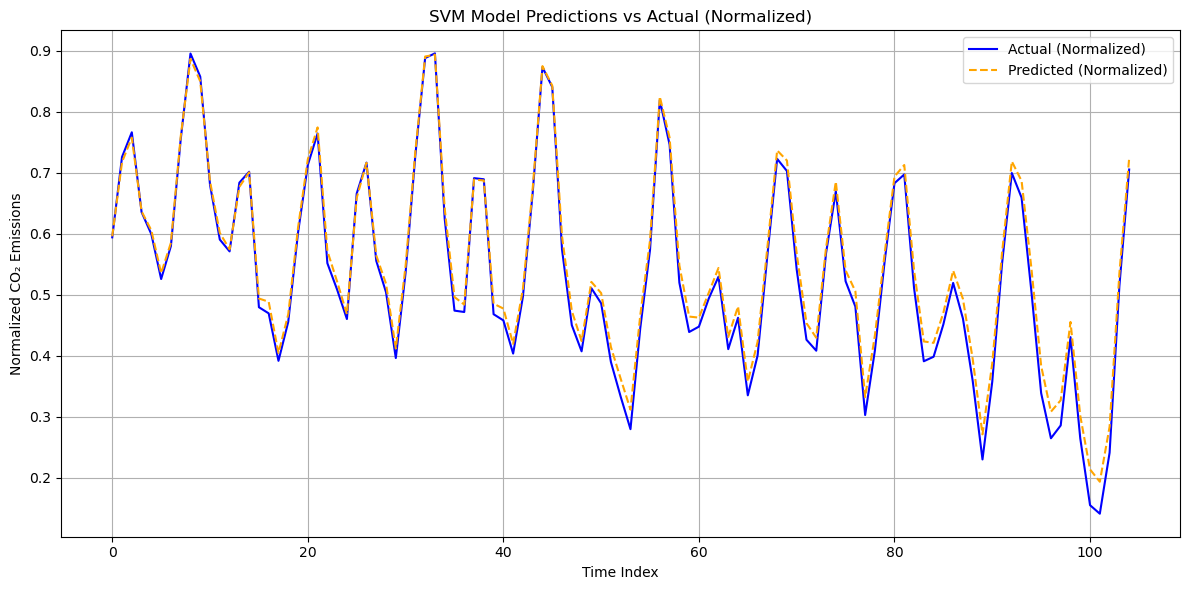

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
data = pd.read_csv('C:/Users/subas/OneDrive/Desktop/MFC/cleaned_monthly_sectoral_dataset.csv')

# Clean column names
data.columns = data.columns.str.strip().str.replace(' ', '_')

# Parse Date and extract time features
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

# Target column
target_col = 'Total_Energy_Electric_Power_Sector_CO2_Emissions'

# Feature Engineering: Lag and Rolling Mean
data['Emission_lag1'] = data[target_col].shift(1)
data['Emission_roll3'] = data[target_col].rolling(window=3).mean()

# Fill missing values
data.fillna(method='ffill', inplace=True)
data.fillna(method='bfill', inplace=True)

# Prepare features and target
features = data.drop(columns=['Date', target_col])
target = data[target_col]

# Normalize features and target
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(features)
y_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

# Time Series Split
tscv = TimeSeriesSplit(n_splits=5)
best_rmse = float('inf')
best_params = None
best_model = None

# Hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 1],
    'epsilon': [0.01, 0.05]
}

# Grid search with time series split
for params in ParameterGrid(param_grid):
    rmses = []
    for train_idx, test_idx in tscv.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

        model = SVR(kernel='rbf', **params)
        model.fit(X_train, y_train.ravel())
        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmses.append(rmse)

    avg_rmse = np.mean(rmses)
    if avg_rmse < best_rmse:
        best_rmse = avg_rmse
        best_params = params

# Final training on full data
final_model = SVR(kernel='rbf', **best_params)
train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]
final_model.fit(X_train, y_train.ravel())
y_pred = final_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", best_params)
print("SVM Model Performance (Normalized):")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot normalized predictions like the second image
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(y_pred, label='Predicted (Normalized)', color='orange', linestyle='--')
plt.xlabel('Time Index')
plt.ylabel('Normalized CO₂ Emissions')
plt.title('SVM Model Predictions vs Actual (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **5. LSTM Model**

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3967 - val_loss: 0.3625
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2342 - val_loss: 0.3569
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2038 - val_loss: 0.3869
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1666 - val_loss: 0.6022
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1754 - val_loss: 0.4423
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1378 - val_loss: 0.2764
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1599 - val_loss: 0.3032
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1355 - val_loss: 0.3202
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1485 - val_loss: 0.1730
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1159 - val_loss: 0.2593
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0959 - val_loss: 0.3686
Epoch 12/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

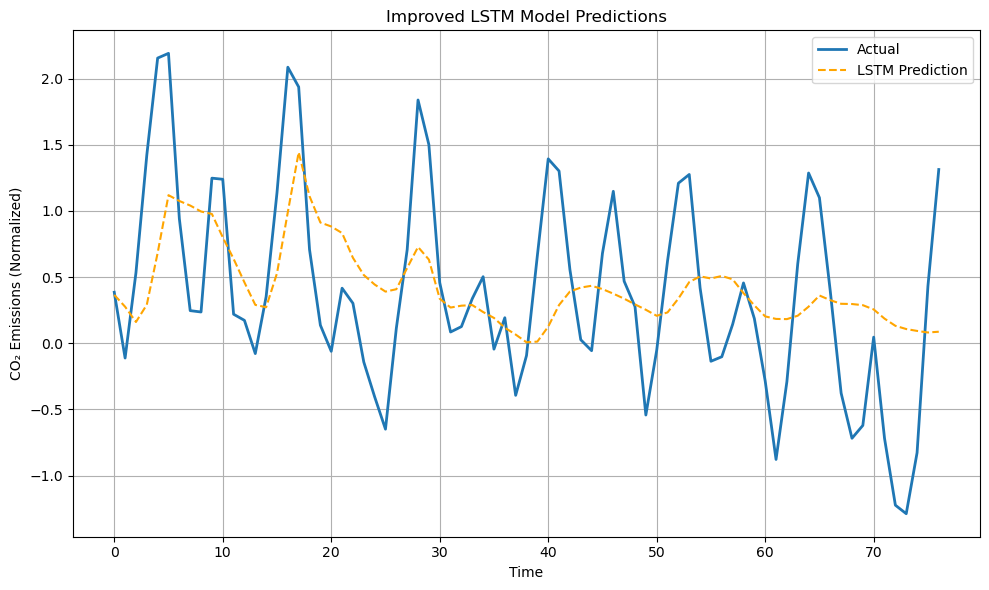

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
data = pd.read_csv('C:/Users/subas/OneDrive/Desktop/MFC/cleaned_monthly_sectoral_dataset.csv')

# Convert 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')

# Handle missing values
data.ffill(inplace=True)
data.bfill(inplace=True)

# Define target column
target_column = 'Total Energy Electric Power Sector CO2 Emissions'

# Drop 'Date' column for features
features = data.drop(columns=['Date'])

# Normalize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_data, columns=features.columns)

# Create sequences
def create_sequences(data, target_col, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data.iloc[i-window_size:i].drop(columns=[target_col]).values)
        y.append(data.iloc[i][target_col])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_df, target_column, window_size)

# Remove any NaNs
mask = ~np.isnan(y)
X, y = X[mask], y[mask]

# Train-test split
split_index = int(0.85 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Define the LSTM model
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Use EarlyStopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Predict
y_pred = model.predict(X_test).flatten()
y_pred = np.nan_to_num(y_pred)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nImproved LSTM Model Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"R²:   {r2:.4f}")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual', linewidth=2)
plt.plot(y_pred, label='LSTM Prediction', linestyle='--', color='orange')
plt.xlabel('Time')
plt.ylabel('CO₂ Emissions (Normalized)')
plt.title('Improved LSTM Model Predictions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


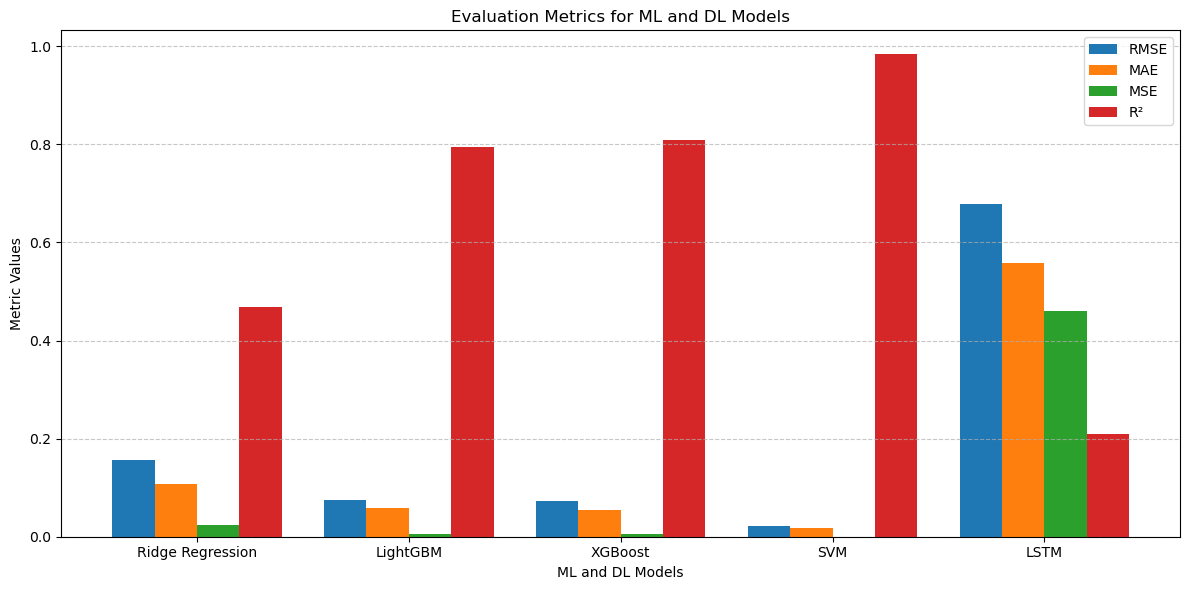

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Ridge Regression', 'LightGBM', 'XGBoost', 'SVM', 'LSTM']

# Evaluation metric values for each model
rmse = [0.157288, 0.0749, 0.0723, 0.0212, 0.6780]
mae  = [0.107850, 0.0584, 0.0542, 0.0176, 0.5590]
mse  = [0.024740, 0.0056, 0.0052, 0.0004, 0.4597]
r2   = [0.467634, 0.7944, 0.8084, 0.9833, 0.2091]

# Bar width and positions
x = np.arange(len(models))
width = 0.2

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, rmse, width, label='RMSE')
plt.bar(x - 0.5*width, mae, width, label='MAE')
plt.bar(x + 0.5*width, mse, width, label='MSE')
plt.bar(x + 1.5*width, r2, width, label='R²')

plt.xlabel('ML and DL Models')
plt.ylabel('Metric Values')
plt.title('Evaluation Metrics for ML and DL Models')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


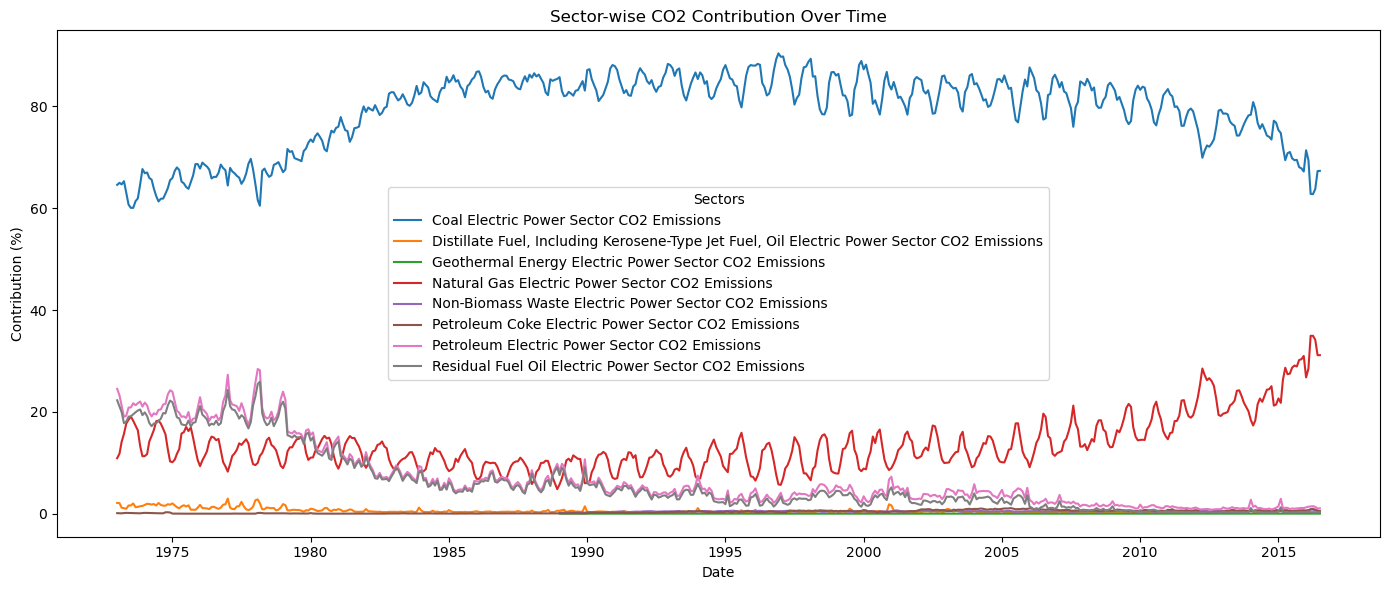

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('C:/Users/subas/OneDrive/Desktop/MFC/cleaned_monthly_sectoral_dataset.csv')

# Convert 'Date' to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Calculate percentage contribution of each sector
percent_df = df.iloc[:, 1:9].div(df['Total Energy Electric Power Sector CO2 Emissions'], axis=0) * 100
percent_df['Date'] = df['Date']

# Plotting the contribution of each sector over time
plt.figure(figsize=(14, 6))
for sector in df.columns[1:9]:  # Using the actual column names (Sector1, Sector2, ...)
    plt.plot(df['Date'], percent_df[sector], label=sector)

plt.legend(title="Sectors")
plt.title("Sector-wise CO2 Contribution Over Time")
plt.xlabel("Date")
plt.ylabel("Contribution (%)")
plt.tight_layout()
plt.show()
